<a href="https://colab.research.google.com/github/qqqwwwaaarr/Balanets/blob/main/BellmanFord1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install osmnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.5 MB/s eta 0:00:00


Délka: 1450 m, uzlů: 48


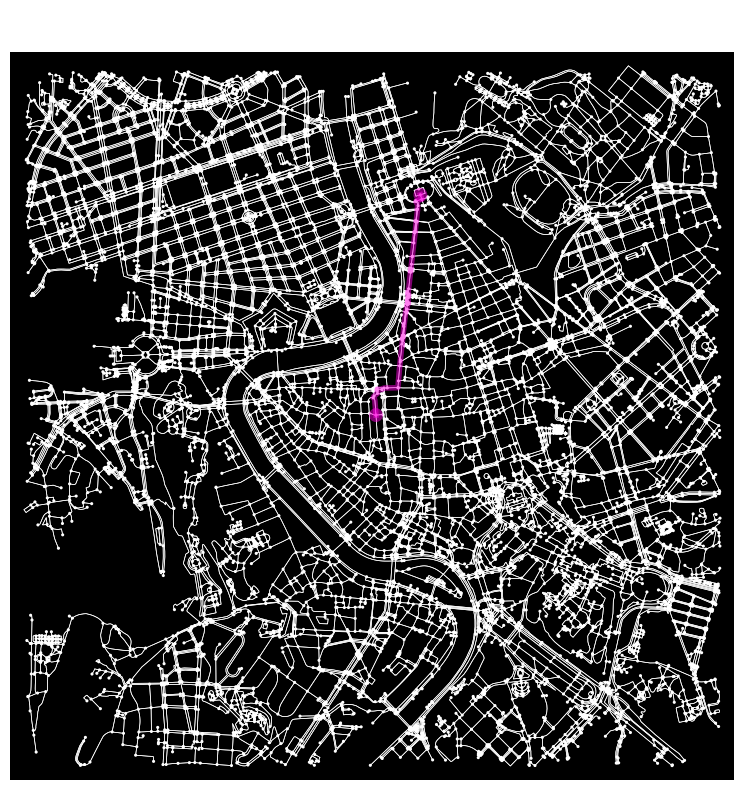

In [7]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# 1. ZÍSKÁNÍ DAT PRO ŘÍM
# 'walk' zajistí, že trasa povede chodníky a pěšími zónami
misto = "Piazza Navona, Rome, Italy"
G = ox.graph_from_address(misto, dist=2000, network_type="walk")

# 2. BELLMAN-FORD ALGORITMUS
def bellman_ford(graf, start, cil):
    uzly = list(graf.nodes)
    hrany = []
    for u, v, k, d in graf.edges(data=True, keys=True):
        hrany.append((u, v, d["length"]))

    dist = {u: float("inf") for u in uzly}
    dist[start] = 0
    odkud = {u: None for u in uzly}

    for _ in range(len(uzly) - 1):
        zmenilo_se = False
        for u, v, vaha in hrany:
            if dist[u] + vaha < dist[v]:
                dist[v] = dist[u] + vaha
                odkud[v] = u
                zmenilo_se = True
        if not zmenilo_se:
            break

    cesta, uzel = [], cil
    while uzel is not None:
        cesta.append(uzel)
        uzel = odkud[uzel]
    cesta.reverse()
    return dist[cil], cesta

# 3. SOUŘADNICE PRO ŘÍM
# Start: Piazza Navona, Cíl: Piazza del Popolo
start_gps = (41.8986, 12.4731)
cil_gps   = (41.9107, 12.4764)

start = ox.nearest_nodes(G, X=start_gps[1], Y=start_gps[0])
cil   = ox.nearest_nodes(G, X=cil_gps[1],  Y=cil_gps[0])

delka, cesta = bellman_ford(G, start, cil)
print(f"Délka: {delka:.0f} m, uzlů: {len(cesta)}")

# 4. VIZUALIZACE
# node_size=5 zajistí, že uzly budou na mapě vidět jako drobné tečky
fig, ax = ox.plot_graph_route(
    G, cesta,
    route_color="#FF00E1",
    route_linewidth=4,
    node_size=5,            # Nastaveno na 5, aby byly vidět body (uzly)
    node_color="white",
    edge_color="white",
    edge_linewidth=0.5,
    bgcolor="black",
    show=False,
    close=False
)

ax.set_title(f"Trasa: Piazza Navona -> Piazza del Popolo ({delka:.0f} m)", color="white", pad=20)
plt.tight_layout()
plt.show()